[Video by Andrej Karpathy](https://www.youtube.com/watch?v=l8pRSuU81PU)

This notebook is thoroughly going through the content of the video as it document and comment for self-education purposes.

*Vibe check to ensure it works at its supposed env*

In [1]:
!python --version

Python 3.11.12


In [2]:
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2024 NVIDIA Corporation
Built on Wed_Oct_30_01:18:48_Pacific_Daylight_Time_2024
Cuda compilation tools, release 12.6, V12.6.85
Build cuda_12.6.r12.6/compiler.35059454_0


*Get cuda to work in GPU if available*

Find your cuda version: https://pytorch.org/get-started/locally/

Replace the url below

In [3]:
# !pip3 install torch --index-url https://download.pytorch.org/whl/cu126

In [4]:
import torch
from torch.nn import functional as F
import math

In [5]:
torch.cuda.is_available()

True

In [6]:
! pip install transformers matplotlib 

*Check if gpu is cuda accessible.*

In [7]:
!nvidia-smi

Mon Jun  9 08:42:36 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 576.52                 Driver Version: 576.52         CUDA Version: 12.9     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3060 Ti   WDDM  |   00000000:01:00.0  On |                  N/A |
| 30%   57C    P2             68W /  225W |    2022MiB /   8192MiB |      5%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# Pre-Text

Related papers,
- [Paper, Attention Is All You Need](https://arxiv.org/abs/1706.03762)
- [GPT-2 Paper, Language Models are Unsupervised Multitask Learners](https://cdn.openai.com/better-language-models/language_models_are_unsupervised_multitask_learners.pdf)
 - [Code for paper](https://github.com/openai/gpt-2)
 - This paper got some errors in calculation and details, where GPT-3's paper can cover for it, which is close in terms of architecture.
- [GPT-3 Paper, Language Models are Few-Shot Learners](https://arxiv.org/abs/2005.14165)
 - [Code for paper](https://github.com/openai/gpt-3)

Supplementary sites for the video,
- [Build nanogpt by Andrej Karpathy](https://github.com/karpathy/build-nanogpt)

Extra to note,
- [LitGPT](https://github.com/Lightning-AI/litgpt)
- [TinyLlama](https://github.com/jzhang38/TinyLlama)

In [8]:
# Note that the model implemented here is the smallest model of GPT-2 with
#   12 layers and 768 channnels/dimensions.
# GPT-2 paper had error during calculation (mentioned in their git repository)

Sources of images, GPT-2 paper

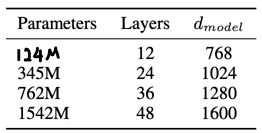

In [9]:
# The bottom chart is to show the validation loss
# of next token prediction in a sequence

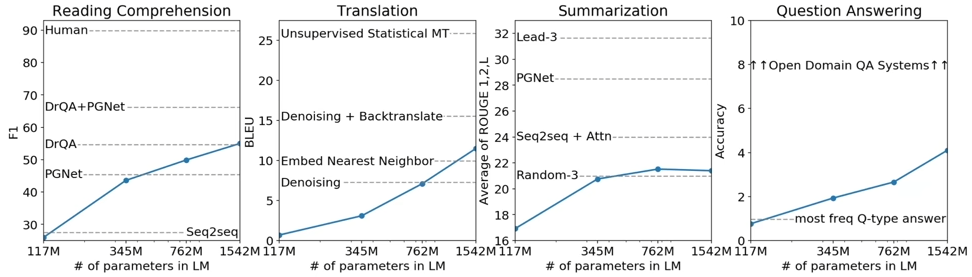

# GPT-2 (124M) Checkpoint exploring: Hugging-face implementation of GPT-2

[Code of GPT-2 by HuggingFace](https://github.com/huggingface/transformers/blob/main/src/transformers/models/gpt2/modeling_gpt2.py)

[HuggingFace page for GPT2](https://huggingface.co/openai-community/gpt2)

In [10]:
# The original GPT-2 code was programmed using Tensorflow
# which is not used as PyTorch nowadays which is friendlier and cleaner.

In [11]:
from transformers import GPT2LMHeadModel
model_hf = GPT2LMHeadModel.from_pretrained("gpt2")    # 124M
# model_hf = GPT2LMHeadModel.from_pretrained("gpt2-xl") # 1542M

# Get raw tensors
sd_hf = model_hf.state_dict()

for k, v in sd_hf.items():
  print(k, v.shape)

# transformer.wte.weight torch.Size([50257, 768])
# 50257 tokens in gpt2 vocabulary
# 768 dimensionsional embedding, vector that represents that token
#     used to capture semantic and syntactic information that token has,
#     preserving important relationships and structures.

# transformer.wpe.weight torch.Size([1024, 768])
# Positional embedding and token embedding.
# GPT2 has maximum context length of 1024,
# Up to 1024 positions that each token can be attending to,
# and each token has 768 fixed vector that is learned by optimization.

# The rest are just weights and biases of the GPT2 transformer
#   transformer.h.0.ln_1.weight torch.Size([768])
#   transformer.h.11.ln_1.weight torch.Size([768])
# There are 12 layers in this Transformer

c:\Users\lukua\anaconda3\envs\AI_GPT2\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


transformer.wte.weight torch.Size([50257, 768])
transformer.wpe.weight torch.Size([1024, 768])
transformer.h.0.ln_1.weight torch.Size([768])
transformer.h.0.ln_1.bias torch.Size([768])
transformer.h.0.attn.c_attn.weight torch.Size([768, 2304])
transformer.h.0.attn.c_attn.bias torch.Size([2304])
transformer.h.0.attn.c_proj.weight torch.Size([768, 768])
transformer.h.0.attn.c_proj.bias torch.Size([768])
transformer.h.0.ln_2.weight torch.Size([768])
transformer.h.0.ln_2.bias torch.Size([768])
transformer.h.0.mlp.c_fc.weight torch.Size([768, 3072])
transformer.h.0.mlp.c_fc.bias torch.Size([3072])
transformer.h.0.mlp.c_proj.weight torch.Size([3072, 768])
transformer.h.0.mlp.c_proj.bias torch.Size([768])
transformer.h.1.ln_1.weight torch.Size([768])
transformer.h.1.ln_1.bias torch.Size([768])
transformer.h.1.attn.c_attn.weight torch.Size([768, 2304])
transformer.h.1.attn.c_attn.bias torch.Size([2304])
transformer.h.1.attn.c_proj.weight torch.Size([768, 768])
transformer.h.1.attn.c_proj.bias 

In [12]:
sd_hf["transformer.wpe.weight"].view(-1)[:20] # weight positional embedding

tensor([-0.0188, -0.1974,  0.0040,  0.0113,  0.0638, -0.1050,  0.0369, -0.1680,
        -0.0491, -0.0565, -0.0025,  0.0135, -0.0042,  0.0151,  0.0166, -0.1381,
        -0.0063, -0.0461,  0.0267, -0.2042])

In [13]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.imshow(sd_hf["transformer.wpe.weight"], cmap="gray")

# Positional embedding has structure.
# Every row in this visualization is a different position.
# A fixed absolute position in the range from 0-1024,
# Each row is representation of that position.

# The positional embedding end up learning
# sine and cosine representation of these positions
# and is pocessed by the Transformer
# to recover all relative positions and realize which token is where
# and attend to them depending on their position, not just content.

In [14]:
# Looking into individual column, grab 3 random columns
plt.plot(sd_hf["transformer.wpe.weight"][:, 150])
plt.plot(sd_hf["transformer.wpe.weight"][:, 200])
plt.plot(sd_hf["transformer.wpe.weight"][:, 250])

# Is a function of position from 0 to 1223

In [15]:
# Green barely fires at 0, likes to fire for everything after 200 up to 800, etc.

# This model is not fully trained, as seen from the jagged-ness (noisy).
# The more trained the model, the smoother the graph.

# It is telling you this is an undertrained model.
# It's kind of a sinusoidal feature during optimization

In [16]:
plt.imshow(sd_hf["transformer.h.1.attn.c_attn.weight"][:300,:300], cmap="gray")
# First layer of transformer, look at its weights
# Some structures can be seen. (mechanistic interpretability <- a new field)

[HuggingFace Pipeline](https://huggingface.co/docs/transformers/en/main_classes/pipelines)

In [17]:
from transformers import pipeline, set_seed
generator = pipeline('text-generation', model='gpt2')
set_seed(42)
generator("Hello, I'm a language model,", max_length=30, num_return_sequences=5)

# Load (raw) weights of this model (released by openAI)
# We can also get pipeline and sample from it.
# Pipeline is a HuggingFace Transformer thing.

# Sample 30 tokens, get 5 sequences.

# Although same seed from GPT-2 HF site, it generated different things.

Device set to use cuda:0
Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=30) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[{'generated_text': "Hello, I'm a language model, so I can write things that are easy to understand with a little bit of code. But when you think of words, it's hard to think of words that are as simple as a little word in a sentence.\n\nSo I'm going to use a little bit of code, and I'll talk a little bit about the syntax.\n\nThis is how you write your first line:\n\n$trans = new $trans [1, 2, 3, 4]; $trans -> write ( 'Hello, I'm a language model, so I can write things that are easier to understand with a little bit of code.' );\n\nThis code is pretty simple, but it really doesn't have to be. We want to write this code in a few lines, and we're going to use an expression, which is a collection of $trans. We'll use the following syntax:\n\n$trans = new $trans [1, 2, 3, 4];\n\nNow what we're going to do is we're going to look for a line that begins with a semicolon, and then uses the word 'hello' in place of a semicolon. We'll also use the following code to write a couple of lines of cod

# Section 1: Implement GPT-2 nn.Module

- [Paper, Attention Is All You Need](https://arxiv.org/abs/1706.03762)

Main differences between Transformer and GPT-2 model.
1. GPT-2 is a `Decoder only` Transformer, it does not have encoder part of Transformer.
2. No Cross Attention (Used for Encoder)

1. Layer Normalization was moved to input of each sub-block (Similar to a pre-activation residual network)
2. An additional Layer Normalization was added after the final self-
attention block.

Transformer architecture

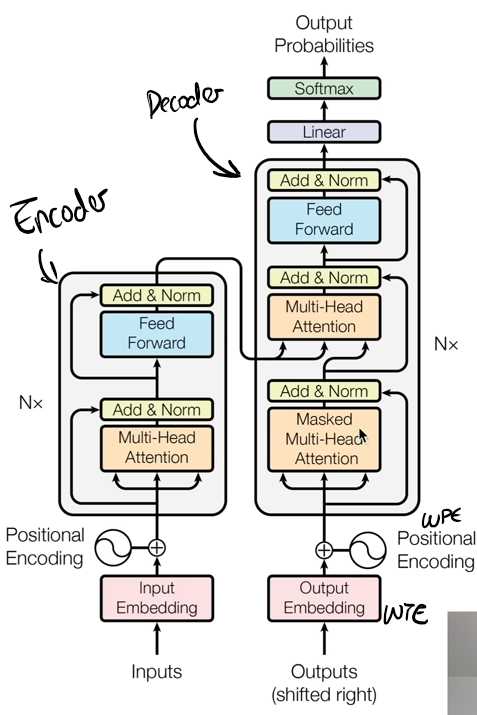

GPT-2 roughly is

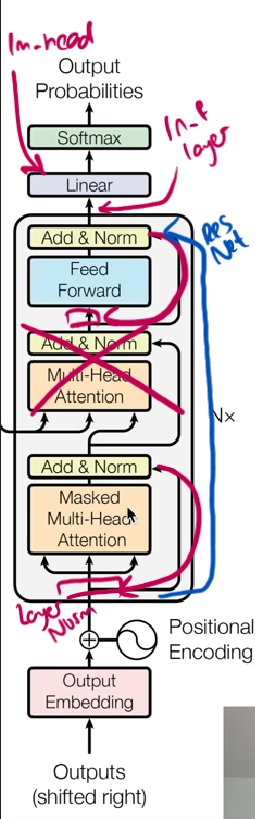

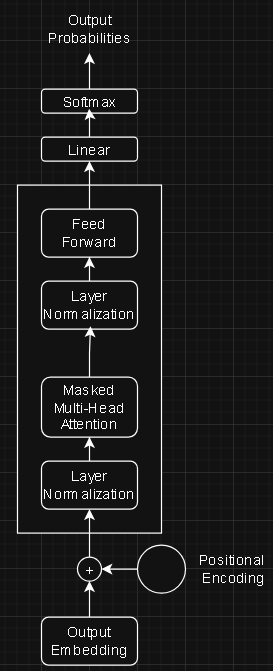

In [18]:
# NOTE:
# The normalization are inside residual stream
#   Feed forward is applied, which goes through normalization
#   Residual pathway has normalizations inside them;
#   Normalization is inside Residual
# We want Residual pathway to be clean,
# from Supervision to inputs of tokens.
# Desirable because gradients flow from top, distributes gradients during backwards.

# This is not ideal nor desirable

## Code

In [19]:
from dataclasses import dataclass
import torch
import torch.nn as nn
from torch.nn import functional as f

In [20]:
@dataclass
class GPTConfig:
  block_size: int = 256
  vocab_size: int = 65
  n_layer: int = 6
  n_head: int = 6
  n_embd: int = 384

class GPT(nn.Module):

  def __init__(self, config):
    super().__init__()
    self.config = config

## Update 1:

In [21]:
@dataclass
class GPTConfig:
  block_size: int = 256
  vocab_size: int = 65
  n_layer: int = 6
  n_head: int = 6
  n_embd: int = 384


class GPT(nn.Module):

  def __init__(self, config):
    super().__init__()
    self.config = config

    self.transformer = nn.ModuleDict(dict(
        wte = nn.Embedding(config.vocab_size, config.n_embd), # Output Embedding
        wpe = nn.Embedding(config.block_size, config.n_embd), # Positional Embedding
        # As seen in the pretrained, h layers can be indexed to create 12 layers
        # h = nn.ModuleList([Block(config) for _ in range(config.n_layer)]), # Nx in image
        ln_f = nn.LayerNorm(config.n_embd),
    ))
    self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)

## Update 2:

In [22]:
class MLP(nn.Module):

  def __init__(self, config):
    super().__init__()
    self.c_fc   = nn.Linear(config.n_embd, 4 * config.n_embd)
    self.gelu   = nn.GELU(approximate='tanh')
    self.c_proj = nn.Linear(4 * config.n_embd, config.n_embd)

  def forward(self, x):
    x = self.c_fc(x)
    x = self.gelu(x)
    x = self.c_proj(x)
    return x

### NOTE: GELU

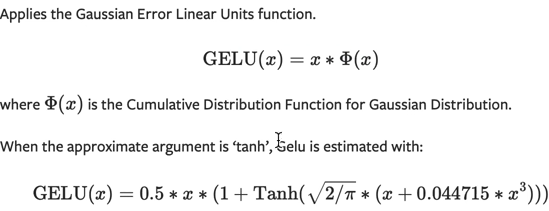

[Source: Pytorch](https://docs.pytorch.org/docs/stable/generated/torch.nn.GELU.html)

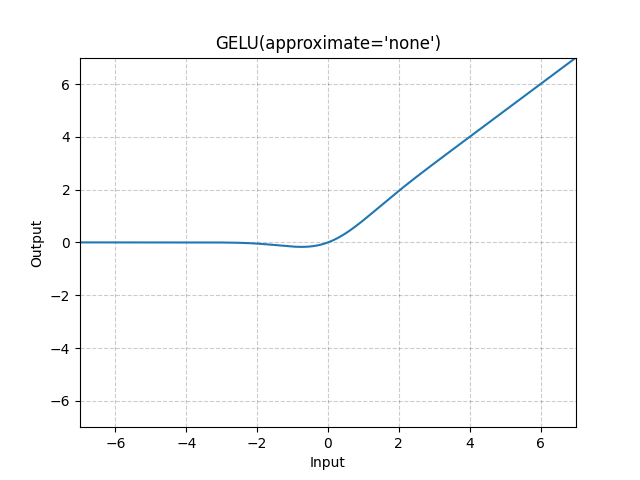

- Basically, it's ReLU but tail is not that flat at 0 Input.
- Kinda like have a fall cushion.GeLU always have a local gradient(Allowing negative inputs close to 0 still get activation instead of flat out 0).
- Removes the "dead ReLU" neurons problem.

NOTE:
- Basically, don't use the approx. version, just use the regular version.

### Code Cont.

In [23]:
class CausalSelfAttention(nn.Module):
  # Multi-Headed Attention

  def __init__(self, config):
    super().__init__()
    assert config.n_embd % config.n_head == 0
    # Key, Query, Value projections for all heads, but in a batch
    self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd)
    # Output projection
    self.c_proj = nn.Linear(config.n_embd, config.n_embd)
    # Regularization
    self.n_head = config.n_head
    self.n_embd = config.n_embd
    # Not really a "bias", closer to a mask
    # Following OpenAI/HF naming
    self.register_buffer("bias", torch.tril(torch.ones(config.block_size, config.block_size))
                                  .view(1, 1, config.block_size, config.block_size))

  def forward(self, x):
    # Batch size, sequence length, embedding dimensionality(n_embd)
    B, T, C = x.size()
    # Calculate Key, Query, Value for all heads in batch
    # and move head forward to be batch
    # nh is "Number of heads", hs is "head size", C (number of channels) = nh * ns
    # E.g. GPT-2 (124M), n_heads=12, hs=64, so nh*hs=C=768 channels in Transformer
    qkv = self.c_attn(x)
    q, k, v = qkv.split(self.n_embd, dim=2)
    k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
    q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
    v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
    # Attention (materializes the large (T, T) matrix for all the queries and keys)
    att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
    att = att.masked_fill(self.bias[:,:,:T,:T]==0, float('-inf')) # Consider tokens before, not after it
    att = F.softmax(att, dim=-1) # Sum = 1
    y = att @ v # (B, nh, T, T) x (B, nh, T, hs) -> (B, nh, T, hs)
    y = y.transpose(1, 2).contiguous().view(B, T, C) # Re-assemble all head outputs side by side
    # Output projection
    y = self.c_proj(y)
    return y

In [24]:
class Block(nn.Module):

  def __init__(self, config):
    super().__init__()
    self.ln_1 = nn.LayerNorm(config.n_embd)
    self.attn = CausalSelfAttention(config) # Reduction
    self.ln_2 = nn.LayerNorm(config.n_embd)
    self.mlp = MLP(config) # Mapping

  def forward(self, x):
    # Residual channel preferably clean
    # from supervision to token input.
    # Gradient flow without normalization in between.
    # From optimization perspective.
    # This is pre-normalization layer. Feed-Forward Network.
    x = x + self.attn(self.ln_1(x))
    x = x + self.mlp(self.ln_2(x))
    # Layer Norm is after Attention
    return x

In [25]:
@dataclass
class GPTConfig:
  block_size: int = 1024 # Max sequence length
  vocab_size: int = 50257 # No. tokens: 50,000 BPE merges + 256 bytes tokens + 1 <|endoftext|>
  n_layer: int = 12 # Number of layers
  n_head: int = 12 # Number of heads
  n_embd: int = 768 # Embedding dimensions

class GPT(nn.Module):

  def __init__(self, config):
    super().__init__()
    self.config = config

    self.transformer = nn.ModuleDict(dict(
        wte = nn.Embedding(config.vocab_size, config.n_embd), # Output Embedding
        wpe = nn.Embedding(config.block_size, config.n_embd), # Positional Embedding
        # As seen in the pretrained, h layers can be indexed to create 12 layers
        h = nn.ModuleList([Block(config) for _ in range(config.n_layer)]), # Nx in image
        ln_f = nn.LayerNorm(config.n_embd),
    ))
    self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)

  @classmethod
  def from_pretrained(cls, model_type):
    """ Loads pretrained GPT-2 model weights from HuggingFace """
    assert model_type in {'gpt2', 'gpt2-medium', 'gpt2-large', 'gpt2-xl'}
    from transformers import GPT2LMHeadModel
    print("loading weights from pretrained gpt: %s" % model_type)

    # n_layer, n_head and n_embd are determined from model_type
    config_args = {
        'gpt2':         dict(n_layer=12, n_head=12, n_embd=768),  # 124M params
        'gpt2-medium':  dict(n_layer=24, n_head=16, n_embd=1024), # 350M params
        'gpt2-large':   dict(n_layer=36, n_head=20, n_embd=1280), # 774M params
        'gpt2-xl':      dict(n_layer=48, n_head=25, n_embd=1600), # 1558M params
    }[model_type]
    config_args['vocab_size'] = 50257 # Always 50257 for GPT model checkpoints
    config_args['block_size'] = 1024 # Always 1024 for GPT model checkpoints
    # Create a from-scratch initialized minGPT model
    config = GPTConfig(**config_args)
    model = GPT(config)
    sd = model.state_dict()
    sd_keys = sd.keys()
    sd_keys = [k for k in sd_keys if not k.endswith('.attn.bias')] # Discard this mask / buffer, not a param

    # Init a huggingface/transformers model
    model_hf = GPT2LMHeadModel.from_pretrained(model_type)
    sd_hf = model_hf.state_dict()

    # Copy while ensuring all of the parameters are aligned and match in names and shapes
    sd_keys_hf = sd_hf.keys()
    sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.masked_bias')] # Ignore, just a buffer
    sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.bias')] # Ignore, just the mask (buffer)
    transposed = ['attn.c_attn.weight', 'attn.c_proj.weight', 'mlp.c_fc.weight', 'mlp.c_proj.weight']
    # Basically OpenAI checkpoints use a "Conv1D" module, but we only want to use a vanilla Linear.
    # This means that we have to transpose these weights when we import them.
    assert len(sd_keys_hf) == len(sd_keys), f"mismatched keys: {len(sd_keys_hf)} != {len(sd_keys)}"
    for k in sd_keys_hf:
        if any(k.endswith(w) for w in transposed):
            # Special treatment for the Conv1D weights we need to transpose
            assert sd_hf[k].shape[::-1] == sd[k].shape
            with torch.no_grad():
                sd[k].copy_(sd_hf[k].t())
        else:
            # Vanilla copy over the other parameters
            assert sd_hf[k].shape == sd[k].shape
            with torch.no_grad():
                sd[k].copy_(sd_hf[k])

    return model

  def forward(self, idx):
    # idx is of shape (B, T)
    B, T = idx.size()
    assert T <= self.config.block_size, f"Cannot forward sequence of length {T}, block size is only {self.config.block_size}"
    # Forward the token and posisition embeddings
    pos = torch.arange(0, T, dtype=torch.long, device=idx.device) # shape (T)
    pos_emb = self.transformer.wpe(pos) # Position embeddings of shape (T, n_embd)
    tok_emb = self.transformer.wte(idx) # Token embeddings of shape (B, T, n_embd)
    x = tok_emb + pos_emb # Broadcasting happening here
    # Forward the blocks of the transformer
    for block in self.transformer.h:
        x = block(x)
    # Forward the final layernorm and the classifier
    x = self.transformer.ln_f(x)
    logits = self.lm_head(x) # (B, T, vocab_size)
    return logits

In [26]:
model = GPT.from_pretrained('gpt2')
print("Loaded")

loading weights from pretrained gpt: gpt2
Loaded


In [27]:
num_return_sequences = 5
max_length = 30

# Commented to avoid error - vibe check
model.eval()
model.to('cuda')

GPT(
  (transformer): ModuleDict(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (h): ModuleList(
      (0-11): 12 x Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): CausalSelfAttention(
          (c_attn): Linear(in_features=768, out_features=2304, bias=True)
          (c_proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): MLP(
          (c_fc): Linear(in_features=768, out_features=3072, bias=True)
          (gelu): GELU(approximate='tanh')
          (c_proj): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [28]:
%pip install tiktoken

Note: you may need to restart the kernel to use updated packages.


In [29]:
import tiktoken 
enc = tiktoken.get_encoding('gpt2')
tokens = enc.encode("Hello, I'm a language model,")
tokens = torch.tensor(tokens, dtype=torch.long) # (8,)
tokens = tokens.unsqueeze(0).repeat(num_return_sequences, 1) # (5, 8)
x = tokens.to('cuda')

In [30]:
# Generate. x = (B,T), B=5, T=8
# Set seed = 42
torch.manual_seed(42)
torch.cuda.manual_seed(42)
while x.size(1) < max_length:
    # Forward the model to get logits
    with torch.no_grad():
        logits = model(x) # (B, T, vocab_size)
        # Take logits at last position (Predicted)
        logits = logits[:, -1, :] # (B, vocab_size)
        # Get probabilities
        probs = F.softmax(logits, dim=-1)
        # Do Top-K sampling of 50 (HugginFace pipeline default)
        # topk_probs = (5, 50)
        # topk_indiecs = (5, 50)
        topk_probs, topk_indices = torch.topk(probs, 50, dim=-1) # DEBUG: Don't know why first time it error "unexpected: dim param"
        # Select a token from top-k probabilities
        ix = torch.multinomial(topk_probs, 1) # (B, 1)
        # Gather corresponding indices
        xcol = torch.gather(topk_indices, -1, ix) # (B, 1)
        # Append to the sequence
        x = torch.cat((x, xcol), dim=1)

#### Note: Auto-detect hardware

In [31]:
device = "cpu"
if torch.cuda.is_available():
    device = "cuda"
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = "mps" # Multi-Process Server
print(f"Using device: {device}")

Using device: cuda


In [32]:
# NOTE: torch.compile actually optimizes the whole process efficiently.

In [33]:
# Print the generated text
for i in range(num_return_sequences):
    tokens = x[i, :max_length].tolist()
    decoded = enc.decode(tokens)
    print(">", decoded)

> Hello, I'm a language model, not a program.

So this morning I started studying for the interview in the lab. This was not
> Hello, I'm a language model, and one of the main things that bothers me when they create languages is how easy it becomes to create something that
> Hello, I'm a language model, and I wrote it off on the grounds that a language model would make me more fluent. But I'm not
> Hello, I'm a language model, I really like languages. I like languages because like, they're good. And the way we talk about languages
> Hello, I'm a language model, a language model I'm using for data modelling. All I did was test the results and then I wrote some


## Training the Dataset

Using TinyShakespear dataset

In [34]:
# Google Colab
# !wget https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt 

# Jupyter Notebook
def get_dataset():
    import urllib.request
    url = 'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt'
    with urllib.request.urlopen(url) as response:
        raw_bytes = response.read()
        text = raw_bytes.decode('utf-8')
        # Equivalent of word count (wc third party library)
        print("Lines: "+ str(len(text.splitlines())), '| Words: ' + str(len(text.split())), '| Bytes: '+ str(len(raw_bytes)))
        # This file only has ASCII characters
    return text

In [35]:
text = get_dataset()
data = text[:1000] # Data is first 1000 characters (~3000 tokens)

Lines: 40000 | Words: 202651 | Bytes: 1115394


In [36]:
# Tokenize it using Tiktoken
tokens = enc.encode(data)
print(tokens[:24])  

[5962, 22307, 25, 198, 8421, 356, 5120, 597, 2252, 11, 3285, 502, 2740, 13, 198, 198, 3237, 25, 198, 5248, 461, 11, 2740, 13]


### Make idx, shape of (B, T) - Training in batch

In [37]:
buf = torch.tensor(tokens[:24+1]) # 24 = B*T # +1 is Ground truth at last token
x = buf[:-1].view(4, 6) # Input to Transformer
y = buf[1:].view(4, 6)# Label for training (with ground truth)
print(x)
print(y) # Final token 198 is the label for 13

tensor([[ 5962, 22307,    25,   198,  8421,   356],
        [ 5120,   597,  2252,    11,  3285,   502],
        [ 2740,    13,   198,   198,  3237,    25],
        [  198,  5248,   461,    11,  2740,    13]])
tensor([[22307,    25,   198,  8421,   356,  5120],
        [  597,  2252,    11,  3285,   502,  2740],
        [   13,   198,   198,  3237,    25,   198],
        [ 5248,   461,    11,  2740,    13,   198]])


In [38]:
# Extra: Set x and y to 'cuda' 
x = x.to('cuda')
y = y.to('cuda')
x.is_cuda, y.is_cuda

(True, True)

### Actual training

Update, forward function

In [39]:
@dataclass
class GPTConfig:
  block_size: int = 1024 # Max sequence length
  vocab_size: int = 50257 # No. tokens: 50,000 BPE merges + 256 bytes tokens + 1 <|endoftext|>
  n_layer: int = 12 # Number of layers
  n_head: int = 12 # Number of heads
  n_embd: int = 768 # Embedding dimensions

class GPT(nn.Module):

  def __init__(self, config):
    super().__init__()
    self.config = config

    self.transformer = nn.ModuleDict(dict(
        wte = nn.Embedding(config.vocab_size, config.n_embd), # Output Embedding
        wpe = nn.Embedding(config.block_size, config.n_embd), # Positional Embedding
        # As seen in the pretrained, h layers can be indexed to create 12 layers
        h = nn.ModuleList([Block(config) for _ in range(config.n_layer)]), # Nx in image
        ln_f = nn.LayerNorm(config.n_embd),
    ))
    self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)

  @classmethod
  def from_pretrained(cls, model_type):
    """ Loads pretrained GPT-2 model weights from HuggingFace """
    assert model_type in {'gpt2', 'gpt2-medium', 'gpt2-large', 'gpt2-xl'}
    from transformers import GPT2LMHeadModel
    print("loading weights from pretrained gpt: %s" % model_type)

    # n_layer, n_head and n_embd are determined from model_type
    config_args = {
        'gpt2':         dict(n_layer=12, n_head=12, n_embd=768),  # 124M params
        'gpt2-medium':  dict(n_layer=24, n_head=16, n_embd=1024), # 350M params
        'gpt2-large':   dict(n_layer=36, n_head=20, n_embd=1280), # 774M params
        'gpt2-xl':      dict(n_layer=48, n_head=25, n_embd=1600), # 1558M params
    }[model_type]
    config_args['vocab_size'] = 50257 # Always 50257 for GPT model checkpoints
    config_args['block_size'] = 1024 # Always 1024 for GPT model checkpoints
    # Create a from-scratch initialized minGPT model
    config = GPTConfig(**config_args)
    model = GPT(config)
    sd = model.state_dict()
    sd_keys = sd.keys()
    sd_keys = [k for k in sd_keys if not k.endswith('.attn.bias')] # Discard this mask / buffer, not a param

    # Init a huggingface/transformers model
    model_hf = GPT2LMHeadModel.from_pretrained(model_type)
    sd_hf = model_hf.state_dict()

    # Copy while ensuring all of the parameters are aligned and match in names and shapes
    sd_keys_hf = sd_hf.keys()
    sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.masked_bias')] # Ignore, just a buffer
    sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.bias')] # Ignore, just the mask (buffer)
    transposed = ['attn.c_attn.weight', 'attn.c_proj.weight', 'mlp.c_fc.weight', 'mlp.c_proj.weight']
    # Basically OpenAI checkpoints use a "Conv1D" module, but we only want to use a vanilla Linear.
    # This means that we have to transpose these weights when we import them.
    assert len(sd_keys_hf) == len(sd_keys), f"mismatched keys: {len(sd_keys_hf)} != {len(sd_keys)}"
    for k in sd_keys_hf:
        if any(k.endswith(w) for w in transposed):
            # Special treatment for the Conv1D weights we need to transpose
            assert sd_hf[k].shape[::-1] == sd[k].shape
            with torch.no_grad():
                sd[k].copy_(sd_hf[k].t())
        else:
            # Vanilla copy over the other parameters
            assert sd_hf[k].shape == sd[k].shape
            with torch.no_grad():
                sd[k].copy_(sd_hf[k])

    return model

  def forward(self, idx, targets=None):
    # idx is of shape (B, T)
    B, T = idx.size()
    assert T <= self.config.block_size, f"Cannot forward sequence of length {T}, block size is only {self.config.block_size}"
    # Forward the token and posisition embeddings
    pos = torch.arange(0, T, dtype=torch.long, device=idx.device) # shape (T)
    pos_emb = self.transformer.wpe(pos) # Position embeddings of shape (T, n_embd)
    tok_emb = self.transformer.wte(idx) # Token embeddings of shape (B, T, n_embd)
    x = tok_emb + pos_emb # Broadcasting happening here
    # Forward the blocks of the transformer
    for block in self.transformer.h:
        x = block(x)
    # Forward the final layernorm and the classifier
    x = self.transformer.ln_f(x)
    logits = self.lm_head(x) # (B, T, vocab_size)
    loss = None
    if targets is not None:
      loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1)) # NOTE: cross-entropy uses 2-D
    return logits, loss

In [40]:
model = GPT(GPTConfig())
# model.to(device)
model.to("cuda")
logits, loss = model(x, y)

logits.shape, loss
# loss = 11.xx
# vocab_size = 50257. Ideally every vocab element is roughly uniform at initialization.
# Cross entropy = -loglikelihood
# -ln(1/50257) = ~10.8 ~= 11

(torch.Size([4, 6, 50257]),
 tensor(10.8935, device='cuda:0', grad_fn=<NllLossBackward0>))

### Optimization loop

[torch AdamW paper](https://docs.pytorch.org/docs/stable/generated/torch.optim.AdamW.html)

Optimizes faster than SGD.

In [41]:
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4) # AdamW is a bug fixed of Adam
steps = 50
for i in range(steps):
    optimizer.zero_grad()
    logits, loss = model(x, y)
    loss.backward()
    optimizer.step()
    print(f"Step {i+1}, Loss: {loss.item()}")

Step 1, Loss: 10.893531799316406
Step 2, Loss: 4.0355305671691895
Step 3, Loss: 1.0962046384811401
Step 4, Loss: 0.335484117269516
Step 5, Loss: 0.13874875009059906
Step 6, Loss: 0.07092411071062088
Step 7, Loss: 0.043900664895772934
Step 8, Loss: 0.031469445675611496
Step 9, Loss: 0.024752596393227577
Step 10, Loss: 0.020613087341189384
Step 11, Loss: 0.01778581738471985
Step 12, Loss: 0.015686705708503723
Step 13, Loss: 0.014022376388311386
Step 14, Loss: 0.012640193104743958
Step 15, Loss: 0.011460659094154835
Step 16, Loss: 0.010441708378493786
Step 17, Loss: 0.009558292105793953
Step 18, Loss: 0.008792183361947536
Step 19, Loss: 0.008127996698021889
Step 20, Loss: 0.007551261689513922
Step 21, Loss: 0.00704897940158844
Step 22, Loss: 0.0066091385670006275
Step 23, Loss: 0.006221339106559753
Step 24, Loss: 0.005876943003386259
Step 25, Loss: 0.005568342749029398
Step 26, Loss: 0.005289976019412279
Step 27, Loss: 0.005037350580096245
Step 28, Loss: 0.004806880839169025
Step 29, Loss

It may look good but this is overfitting. The model is memorizing this single individual batch data.

We don't want to overfit a single batch, we want to <u>optimize and iterate over XY batches</u>. We need a dataloader. 

#### Data loader lite

In [42]:
import tiktoken
class DataLoaderLite:
    
    def __init__(self, B, T):
        self.B = B
        self.T = T
    
        # At init, load tokens from disk and store in memory
        text = get_dataset()
        enc = tiktoken.get_encoding('gpt2')
        tokens = enc.encode(text)
        self.tokens = torch.tensor(tokens)
        print(f"Loaded {len(self.tokens)} tokens.")
        print(f"1 epoch = {len(self.tokens) // (B*T)} batches.")
        
        # State
        self.current_position = 0
        
    def next_batch(self):
        B, T = self.B, self.T
        buf = self.tokens[self.current_position : self.current_position+B*T+1]
        x = (buf[:-1]).view(B, T) # Inputs
        y = (buf[1:]).view(B, T)  # Labels/Targets
        # Advance the position in tensor
        self.current_position += B * T
        # If loading next batch would be out of bounds, reset
        if self.current_position + (B * T + 1) > len(self.tokens):
            self.current_position = 0
        return x, y

In [43]:
train_loader = DataLoaderLite(B=4, T=32)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4) # AdamW is a bug fixed of Adam
steps = 50
for i in range(steps):
    x, y = train_loader.next_batch()
    x, y = x.to(device), y.to(device)
    optimizer.zero_grad()
    logits, loss = model(x, y)
    loss.backward()
    optimizer.step()
    print(f"Step {i+1}, Loss: {loss.item()}") 

Lines: 40000 | Words: 202651 | Bytes: 1115394
Loaded 338025 tokens.
1 epoch = 2640 batches.
Step 1, Loss: 7.816649436950684
Step 2, Loss: 11.133648872375488
Step 3, Loss: 11.369466781616211
Step 4, Loss: 10.043525695800781
Step 5, Loss: 9.527843475341797
Step 6, Loss: 9.036558151245117
Step 7, Loss: 9.671113014221191
Step 8, Loss: 9.04454231262207
Step 9, Loss: 8.24924087524414
Step 10, Loss: 8.321388244628906
Step 11, Loss: 8.483295440673828
Step 12, Loss: 7.28394889831543
Step 13, Loss: 7.902468681335449
Step 14, Loss: 7.531759262084961
Step 15, Loss: 7.74044132232666
Step 16, Loss: 7.375670433044434
Step 17, Loss: 7.407822608947754
Step 18, Loss: 8.368481636047363
Step 19, Loss: 7.325920104980469
Step 20, Loss: 7.868858814239502
Step 21, Loss: 7.688366413116455
Step 22, Loss: 7.872047424316406
Step 23, Loss: 6.336824893951416
Step 24, Loss: 6.7795820236206055
Step 25, Loss: 6.695058345794678
Step 26, Loss: 6.436450481414795
Step 27, Loss: 6.5717692375183105
Step 28, Loss: 7.54010343

### BUG: lm_head and wte + Model initialization

Checking lm_head (Top layer at input, upscaling 768 to 50257) and wte (Bottom layer at logits)

In [44]:
sd_hf["lm_head.weight"].shape, sd_hf["transformer.wte.weight"].shape

(torch.Size([50257, 768]), torch.Size([50257, 768]))

In [45]:
# Comparing element-wise equality
(sd_hf["lm_head.weight"] == sd_hf["transformer.wte.weight"]).all()

tensor(True)

In [46]:
# Check data pointers
sd_hf["lm_head.weight"].data_ptr(), sd_hf["transformer.wte.weight"].data_ptr()

(1236614098899, 1236614098899)

These 2 separate tensors not only have the same shapes and elements, they are pointing to the identical tensor.

<u>This is because this is a common weight tying scheme.</u>
> Similar tokens should have similar embeddings or similar weights.

[Paper, Using Output Embedding to Improve Language Models](https://arxiv.org/pdf/1608.05859) | [Paper, Attention is all you need](https://arxiv.org/pdf/1706.03762)

In [47]:
# Basically just add () to init
# Weight Sharing Scheme
# self.transformer.wte.weight = self.lm_head.weight

# Copies reference from top layer directly.

In [48]:
# Esssentially 50257 * 768 = ~ 40M parameters
# 40/124 ~= 32% 
# 32% parameters saved simply doing Bottom Layer = Top Layer
# Because holistically, they should be the same

In [49]:
class GPT(nn.Module):

  def __init__(self, config):
    super().__init__()
    self.config = config

    self.transformer = nn.ModuleDict(dict(
        wte = nn.Embedding(config.vocab_size, config.n_embd), # Output Embedding
        wpe = nn.Embedding(config.block_size, config.n_embd), # Positional Embedding
        # As seen in the pretrained, h layers can be indexed to create 12 layers
        h = nn.ModuleList([Block(config) for _ in range(config.n_layer)]), # Nx in image
        ln_f = nn.LayerNorm(config.n_embd),
    ))
    self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)
    
    # Weight Sharing Scheme
    self.transformer.wte.weight = self.lm_head.weight
    
    # Init param
    self.apply(self._init_weights)
    
  def _init_weights(self, module):
    if isinstance(module, nn.Linear):
      # NOTE: std=0.02 because d_head in GPT2 roughly results the same - Check back to initialization notebook
      torch.nn.init.normal_(module.weight, mean=0.0, std=0.02) 
      if module.bias is not None:
        torch.nn.init.zeros_(module.bias) # module.bias is defaulted at uniform, not zero
    elif isinstance(module, nn.Embedding):
      torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

  @classmethod
  def from_pretrained(cls, model_type):
    """ Loads pretrained GPT-2 model weights from HuggingFace """
    assert model_type in {'gpt2', 'gpt2-medium', 'gpt2-large', 'gpt2-xl'}
    from transformers import GPT2LMHeadModel
    print("loading weights from pretrained gpt: %s" % model_type)

    # n_layer, n_head and n_embd are determined from model_type
    config_args = {
        'gpt2':         dict(n_layer=12, n_head=12, n_embd=768),  # 124M params
        'gpt2-medium':  dict(n_layer=24, n_head=16, n_embd=1024), # 350M params
        'gpt2-large':   dict(n_layer=36, n_head=20, n_embd=1280), # 774M params
        'gpt2-xl':      dict(n_layer=48, n_head=25, n_embd=1600), # 1558M params
    }[model_type]
    config_args['vocab_size'] = 50257 # Always 50257 for GPT model checkpoints
    config_args['block_size'] = 1024 # Always 1024 for GPT model checkpoints
    # Create a from-scratch initialized minGPT model
    config = GPTConfig(**config_args)
    model = GPT(config)
    sd = model.state_dict()
    sd_keys = sd.keys()
    sd_keys = [k for k in sd_keys if not k.endswith('.attn.bias')] # Discard this mask / buffer, not a param

    # Init a huggingface/transformers model
    model_hf = GPT2LMHeadModel.from_pretrained(model_type)
    sd_hf = model_hf.state_dict()

    # Copy while ensuring all of the parameters are aligned and match in names and shapes
    sd_keys_hf = sd_hf.keys()
    sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.masked_bias')] # Ignore, just a buffer
    sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.bias')] # Ignore, just the mask (buffer)
    transposed = ['attn.c_attn.weight', 'attn.c_proj.weight', 'mlp.c_fc.weight', 'mlp.c_proj.weight']
    # Basically OpenAI checkpoints use a "Conv1D" module, but we only want to use a vanilla Linear.
    # This means that we have to transpose these weights when we import them.
    assert len(sd_keys_hf) == len(sd_keys), f"mismatched keys: {len(sd_keys_hf)} != {len(sd_keys)}"
    for k in sd_keys_hf:
        if any(k.endswith(w) for w in transposed):
            # Special treatment for the Conv1D weights we need to transpose
            assert sd_hf[k].shape[::-1] == sd[k].shape
            with torch.no_grad():
                sd[k].copy_(sd_hf[k].t())
        else:
            # Vanilla copy over the other parameters
            assert sd_hf[k].shape == sd[k].shape
            with torch.no_grad():
                sd[k].copy_(sd_hf[k])

    return model

  def forward(self, idx, targets=None):
    # idx is of shape (B, T)
    B, T = idx.size()
    assert T <= self.config.block_size, f"Cannot forward sequence of length {T}, block size is only {self.config.block_size}"
    # Forward the token and posisition embeddings
    pos = torch.arange(0, T, dtype=torch.long, device=idx.device) # shape (T)
    pos_emb = self.transformer.wpe(pos) # Position embeddings of shape (T, n_embd)
    tok_emb = self.transformer.wte(idx) # Token embeddings of shape (B, T, n_embd)
    x = tok_emb + pos_emb # Broadcasting happening here
    # Forward the blocks of the transformer
    for block in self.transformer.h:
        x = block(x)
    # Forward the final layernorm and the classifier
    x = self.transformer.ln_f(x)
    logits = self.lm_head(x) # (B, T, vocab_size)
    loss = None
    if targets is not None:
      loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1)) # NOTE: cross-entropy uses 2-D
    return logits, loss

### Scaling Init Weights

> We scale the weights of residual layers at initialization by a factor of 1/√N where N is the number of residual layers.

GPT2 paper authors.

In [50]:
# Example
# Standard deviation grows inside residual Stream
x = torch.zeros(768)
n = 100 # E.g. 100 layers
for i in range(n):
    # x += torch.randn(768) # tensor(10.0753)
    
    # Scale down every foo's contributions into residual stream
    # By 1/sqrt(n)
    x += n**-0.5 * torch.randn(768) # tensor(0.9804) # Control the growth
print(x.std())

tensor(0.9812)


In [51]:
class MLP(nn.Module):

  def __init__(self, config):
    super().__init__()
    self.c_fc   = nn.Linear(config.n_embd, 4 * config.n_embd)
    self.gelu   = nn.GELU(approximate='tanh')
    self.c_proj = nn.Linear(4 * config.n_embd, config.n_embd)
    self.c_proj.NANOGPT_SCALE_INIT = 1 # Flag for scaling init 

  def forward(self, x):
    x = self.c_fc(x)
    x = self.gelu(x)
    x = self.c_proj(x)
    return x

In [52]:
# GPT2: scale down at c_proj
class CausalSelfAttention(nn.Module):
  # Multi-Headed Attention

  def __init__(self, config):
    super().__init__()
    assert config.n_embd % config.n_head == 0
    # Key, Query, Value projections for all heads, but in a batch
    self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd)
    # Output projection
    self.c_proj = nn.Linear(config.n_embd, config.n_embd)
    self.c_proj.NANOGPT_SCALE_INIT = 1 # Flag for scaling init 
    
    # Regularization
    self.n_head = config.n_head
    self.n_embd = config.n_embd
    # Not really a "bias", closer to a mask
    # Following OpenAI/HF naming
    self.register_buffer("bias", torch.tril(torch.ones(config.block_size, config.block_size))
                                  .view(1, 1, config.block_size, config.block_size))

  def forward(self, x):
    # Batch size, sequence length, embedding dimensionality(n_embd)
    B, T, C = x.size()
    # Calculate Key, Query, Value for all heads in batch
    # and move head forward to be batch
    # nh is "Number of heads", hs is "head size", C (number of channels) = nh * ns
    # E.g. GPT-2 (124M), n_heads=12, hs=64, so nh*hs=C=768 channels in Transformer
    qkv = self.c_attn(x)
    q, k, v = qkv.split(self.n_embd, dim=2)
    k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
    q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
    v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
    # Attention (materializes the large (T, T) matrix for all the queries and keys)
    att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
    att = att.masked_fill(self.bias[:,:,:T,:T]==0, float('-inf')) # Consider tokens before, not after it
    att = F.softmax(att, dim=-1) # Sum = 1
    y = att @ v # (B, nh, T, T) x (B, nh, T, hs) -> (B, nh, T, hs)
    y = y.transpose(1, 2).contiguous().view(B, T, C) # Re-assemble all head outputs side by side
    # Output projection
    y = self.c_proj(y)
    return y

In [53]:
class GPT(nn.Module):

  def __init__(self, config):
    super().__init__()
    self.config = config

    self.transformer = nn.ModuleDict(dict(
        wte = nn.Embedding(config.vocab_size, config.n_embd), # Output Embedding
        wpe = nn.Embedding(config.block_size, config.n_embd), # Positional Embedding
        # As seen in the pretrained, h layers can be indexed to create 12 layers
        h = nn.ModuleList([Block(config) for _ in range(config.n_layer)]), # Nx in image
        ln_f = nn.LayerNorm(config.n_embd),
    ))
    self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)
    
    # Weight Sharing Scheme
    self.transformer.wte.weight = self.lm_head.weight
    
    # Init param
    self.apply(self._init_weights)
    
  def _init_weights(self, module):
    if isinstance(module, nn.Linear):
        std = 0.02
        if hasattr(module, 'NANOGPT_SCALE_INIT'):
            std *= (2 * self.config.n_layer) ** -0.5
        # NOTE: that std=0.02 because d_head in GPT2 roughly results the same - Check back to initialization notebook
        torch.nn.init.normal_(module.weight, mean=0.0, std=std) 
        if module.bias is not None:
            torch.nn.init.zeros_(module.bias) # module.bias is defaulted at uniform, not zero
    elif isinstance(module, nn.Embedding):
        torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

  @classmethod
  def from_pretrained(cls, model_type):
    """ Loads pretrained GPT-2 model weights from HuggingFace """
    assert model_type in {'gpt2', 'gpt2-medium', 'gpt2-large', 'gpt2-xl'}
    from transformers import GPT2LMHeadModel
    print("loading weights from pretrained gpt: %s" % model_type)

    # n_layer, n_head and n_embd are determined from model_type
    config_args = {
        'gpt2':         dict(n_layer=12, n_head=12, n_embd=768),  # 124M params
        'gpt2-medium':  dict(n_layer=24, n_head=16, n_embd=1024), # 350M params
        'gpt2-large':   dict(n_layer=36, n_head=20, n_embd=1280), # 774M params
        'gpt2-xl':      dict(n_layer=48, n_head=25, n_embd=1600), # 1558M params
    }[model_type]
    config_args['vocab_size'] = 50257 # Always 50257 for GPT model checkpoints
    config_args['block_size'] = 1024 # Always 1024 for GPT model checkpoints
    # Create a from-scratch initialized minGPT model
    config = GPTConfig(**config_args)
    model = GPT(config)
    sd = model.state_dict()
    sd_keys = sd.keys()
    sd_keys = [k for k in sd_keys if not k.endswith('.attn.bias')] # Discard this mask / buffer, not a param

    # Init a huggingface/transformers model
    model_hf = GPT2LMHeadModel.from_pretrained(model_type)
    sd_hf = model_hf.state_dict()

    # Copy while ensuring all of the parameters are aligned and match in names and shapes
    sd_keys_hf = sd_hf.keys()
    sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.masked_bias')] # Ignore, just a buffer
    sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.bias')] # Ignore, just the mask (buffer)
    transposed = ['attn.c_attn.weight', 'attn.c_proj.weight', 'mlp.c_fc.weight', 'mlp.c_proj.weight']
    # Basically OpenAI checkpoints use a "Conv1D" module, but we only want to use a vanilla Linear.
    # This means that we have to transpose these weights when we import them.
    assert len(sd_keys_hf) == len(sd_keys), f"mismatched keys: {len(sd_keys_hf)} != {len(sd_keys)}"
    for k in sd_keys_hf:
        if any(k.endswith(w) for w in transposed):
            # Special treatment for the Conv1D weights we need to transpose
            assert sd_hf[k].shape[::-1] == sd[k].shape
            with torch.no_grad():
                sd[k].copy_(sd_hf[k].t())
        else:
            # Vanilla copy over the other parameters
            assert sd_hf[k].shape == sd[k].shape
            with torch.no_grad():
                sd[k].copy_(sd_hf[k])

    return model

  def forward(self, idx, targets=None):
    # idx is of shape (B, T)
    B, T = idx.size()
    assert T <= self.config.block_size, f"Cannot forward sequence of length {T}, block size is only {self.config.block_size}"
    # Forward the token and posisition embeddings
    pos = torch.arange(0, T, dtype=torch.long, device=idx.device) # shape (T)
    pos_emb = self.transformer.wpe(pos) # Position embeddings of shape (T, n_embd)
    tok_emb = self.transformer.wte(idx) # Token embeddings of shape (B, T, n_embd)
    x = tok_emb + pos_emb # Broadcasting happening here
    # Forward the blocks of the transformer
    for block in self.transformer.h:
        x = block(x)
    # Forward the final layernorm and the classifier
    x = self.transformer.ln_f(x)
    logits = self.lm_head(x) # (B, T, vocab_size)
    loss = None
    if targets is not None:
      loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1)) # NOTE: cross-entropy uses 2-D
    return logits, loss

In [54]:
def main():
  device = "cpu"
  if torch.cuda.is_available():
      device = "cuda"
  elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
      device = "mps" # Multi-Process Server
  print(f"Using device: {device}")
  
  torch.manual_seed(1337)
  if torch.cuda.is_available():
    torch.cuda.manual_seed(1337)
  
  # Dataset 
  text = get_dataset()
  """ Replaced with DataLoaderLite
  # Get databatch 
  enc = tiktoken.get_encoding('gpt2')
  data = text[:1000] # Data is first 1000 characters (~3000 tokens)
  tokens = enc.encode(data)
  buf = torch.tensor(tokens[:24+1]) # 24 = B*T # +1 is Ground truth at last token
  x = buf[:-1].view(4, 6) # Input to Transformer
  y = buf[1:].view(4, 6)# Label for training (with ground truth) 
  """
   
  train_loader = DataLoaderLite(B=4, T=32)
  
  # Model, get logits
  model = GPT(GPTConfig())
  model.to(device) 
  
  # Optimizer
  optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4) # AdamW is a bug fixed of Adam
  steps = 50
  for i in range(steps):
    x, y = train_loader.next_batch()
    x, y = x.to(device), y.to(device)
    optimizer.zero_grad()
    logits, loss = model(x, y)

    loss.backward()
    optimizer.step()
    print(f"Step {i+1}, Loss: {loss.item()}")
    
main()

Using device: cuda
Lines: 40000 | Words: 202651 | Bytes: 1115394
Lines: 40000 | Words: 202651 | Bytes: 1115394
Loaded 338025 tokens.
1 epoch = 2640 batches.
Step 1, Loss: 10.960027694702148
Step 2, Loss: 9.687705993652344
Step 3, Loss: 9.082898139953613
Step 4, Loss: 9.145989418029785
Step 5, Loss: 8.626201629638672
Step 6, Loss: 8.33169937133789
Step 7, Loss: 8.897953033447266
Step 8, Loss: 8.837982177734375
Step 9, Loss: 8.116044044494629
Step 10, Loss: 8.042160034179688
Step 11, Loss: 8.38084888458252
Step 12, Loss: 7.435605525970459
Step 13, Loss: 7.8245649337768555
Step 14, Loss: 7.458940505981445
Step 15, Loss: 7.5318756103515625
Step 16, Loss: 7.366677761077881
Step 17, Loss: 7.436797618865967
Step 18, Loss: 8.293567657470703
Step 19, Loss: 7.2027997970581055
Step 20, Loss: 7.8870320320129395
Step 21, Loss: 7.505932331085205
Step 22, Loss: 7.82287073135376
Step 23, Loss: 6.425383567810059
Step 24, Loss: 6.877799034118652
Step 25, Loss: 6.827327728271484
Step 26, Loss: 6.70185422

## Tensor Cores - Timing code, TF32 Precision, 333ms

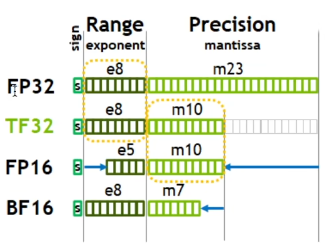

https://www.youtube.com/watch?v=l8pRSuU81PU - 1:28:14 

Andrej explains about TF32, NVidia GPU terms.

In [55]:
"""
# Notably, tensors in the model above are in fp32 (float32) format.
# This is wasteful and slow as it takes a massive byte per tensor. 

# Watch the timing above as Andrej explains.

# TF32 cut off mantissa (precision) bits for faster and more efficient training 
# in exchange for a bit of precision fuzziness.

# Use T32 format by using the following code:
"""
# torch.set_float32_matmul_precision('high')


'\n# Notably, tensors in the model above are in fp32 (float32) format.\n# This is wasteful and slow as it takes a massive byte per tensor. \n\n# Watch the timing above as Andrej explains.\n\n# TF32 cut off mantissa (precision) bits for faster and more efficient training \n# in exchange for a bit of precision fuzziness.\n\n# Use T32 format by using the following code:\n'

In [56]:
# Timing Code
# CPU sent to GPU to do work, but stays idle.
# Timing to stop this bottleneck effect
# torch.cuda.synchronize()

# Expect the first one to be slower due to initialization, buffers etc

In [57]:
#   train_loader = DataLoaderLite(B=4, T=32)

# You can change the B and T to fit for your GPU, the larger the more expensive.
# Use integers that is divisible; to the power of 2: 2^2,3,4,...

In [58]:
def main():
  device = "cpu"
  if torch.cuda.is_available():
      device = "cuda"
  elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
      device = "mps" # Multi-Process Server
  print(f"Using device: {device}")
  
  torch.manual_seed(1337)
  if torch.cuda.is_available():
    torch.cuda.manual_seed(1337)
  
  train_loader = DataLoaderLite(B=4, T=32)
  
  # Use T32 Format
  torch.set_float32_matmul_precision('high')
  
  # Model, get logits
  model = GPT(GPTConfig())
  model.to(device) 
  
  # Optimizer
  optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4) # AdamW is a bug fixed of Adam
  steps = 50
  import time
  for i in range(steps):
    t0 = time.time()
    x, y = train_loader.next_batch()
    x, y = x.to(device), y.to(device)
    optimizer.zero_grad()
    logits, loss = model(x, y)
    loss.backward()
    optimizer.step()
    torch.cuda.synchronize()
    t1 = time.time()
    dt = (t1 - t0)*1000 # Time difference in milliseconds
    tokens_per_sec = (train_loader.B * train_loader.T) / (t1 - t0)
    print(f"Step {i+1}, Loss: {loss.item()}, Dt: {dt:.2f}ms, tok/sec: {tokens_per_sec:.2f}")
    
main()

Using device: cuda
Lines: 40000 | Words: 202651 | Bytes: 1115394
Loaded 338025 tokens.
1 epoch = 2640 batches.
Step 1, Loss: 10.960087776184082, Dt: 62.51ms, tok/sec: 2047.61
Step 2, Loss: 9.687814712524414, Dt: 48.49ms, tok/sec: 2639.92
Step 3, Loss: 9.082820892333984, Dt: 47.52ms, tok/sec: 2693.85
Step 4, Loss: 9.145929336547852, Dt: 50.97ms, tok/sec: 2511.44
Step 5, Loss: 8.626152038574219, Dt: 48.02ms, tok/sec: 2665.38
Step 6, Loss: 8.33167552947998, Dt: 44.51ms, tok/sec: 2875.66
Step 7, Loss: 8.898016929626465, Dt: 44.50ms, tok/sec: 2876.29
Step 8, Loss: 8.837984085083008, Dt: 45.34ms, tok/sec: 2823.02
Step 9, Loss: 8.116010665893555, Dt: 44.51ms, tok/sec: 2875.93
Step 10, Loss: 8.042126655578613, Dt: 42.76ms, tok/sec: 2993.59
Step 11, Loss: 8.380830764770508, Dt: 49.97ms, tok/sec: 2561.53
Step 12, Loss: 7.435542106628418, Dt: 45.03ms, tok/sec: 2842.50
Step 13, Loss: 7.824506759643555, Dt: 46.51ms, tok/sec: 2752.31
Step 14, Loss: 7.458910942077637, Dt: 45.51ms, tok/sec: 2812.33
St

**<u>Important Note: Tokens per seconds is important!</u>**

Note: Not all GPU has T32 format, older ones may not have it.

In [59]:
# Highest setting (F32)
# Step 1, Loss: 10.93676471710205, Dt: 449.78ms, tok/sec: 1138.34

# High setting (T32)
# Step 1, Loss: 10.936789512634277, Dt: 408.58ms, tok/sec: 1253.12

## Float16, Gradient Scalers, bfloat16, 300ms

Reducing more precision bits.- bfloat16